In [186]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pywin.Demos.openGLDemo import threeto8

titanic = pd.read_csv("titanic.csv")
titanic = titanic.drop(columns=["Cabin"])
titanic.Age = titanic.Age.fillna(titanic.Age.mean())
titanic.Embarked = titanic.Embarked.fillna(titanic.Embarked.mode()[0])



female survival rate is higher: 0.74 compared to 0.19. A difference of: 0.55


<Axes: xlabel='Sex', ylabel='Survived'>

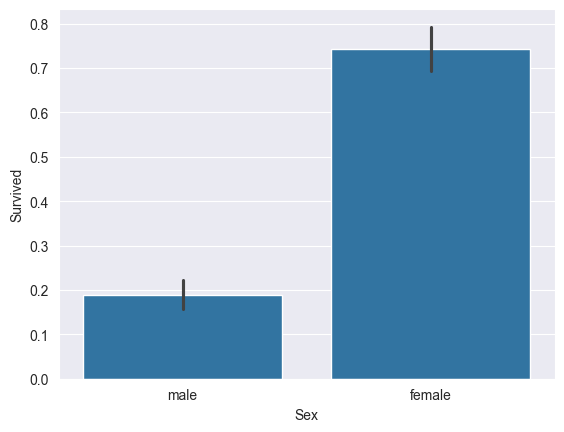

In [187]:
survival_rate_sex = titanic.groupby("Sex")["Survived"].mean()
delta = survival_rate_sex.female - survival_rate_sex.male
if survival_rate_sex.female > 0.5:
    print(f"female survival rate is higher: {survival_rate_sex.female:.2f} "
          f"compared to {survival_rate_sex.male:.2f}. A difference of: {delta:.2f}")
elif survival_rate_sex.male > 0.5:
    print("male survival rate is higher")
else:
    print("There is no equality, this print will never happen.")
sns.barplot(x=titanic.Sex, y=titanic.Survived)

<Axes: xlabel='Pclass,Sex'>

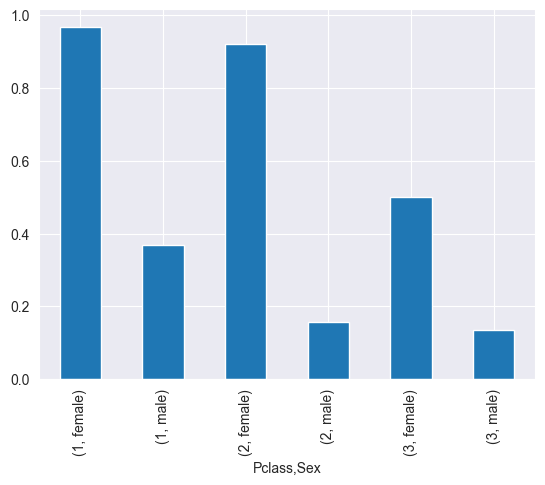

In [235]:
kk = titanic.groupby(["Pclass", "Sex"])["Survived"].mean()
kk.plot(kind='bar')

In [300]:
parch = titanic.query("SibSp == 0")
parch["avg_price"] = parch.Fare / (parch["Parch"] + 1)
mean = parch.groupby(["Parch", "Pclass"])["Fare"].mean()


print(mean)


Parch  Pclass
0      1          63.672514
       2          14.066106
       3           9.272052
1      1         129.288379
       2          25.375000
       3          12.036000
2      1         100.979622
       2          24.750525
       3          17.132283
3      3          19.258300
4      3          21.075000
5      3          34.406250
Name: Fare, dtype: float64


C:\Users\merda\AppData\Local\Temp\ipykernel_3480\1333881706.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  parch["avg_price"] = parch.Fare / (parch["Parch"] + 1)


<Axes: xlabel='Parch'>

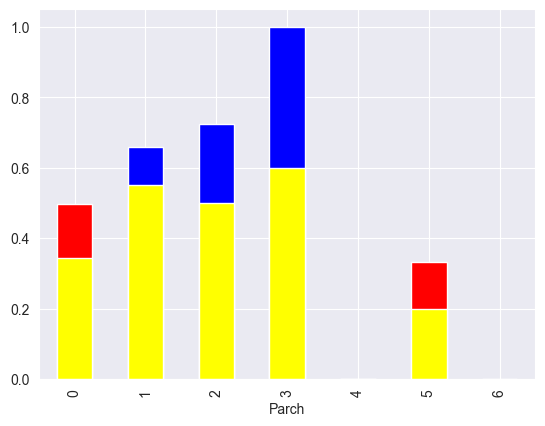

In [315]:
titanic.query("SibSp == 0").groupby("Parch")["Survived"].mean().plot(kind="bar",color="blue")
titanic.query("SibSp != 0").groupby("Parch")["Survived"].mean().plot(kind="bar",color="red")
titanic.groupby("Parch")["Survived"].mean().plot(kind="bar",color="yellow")